# Analyse Delta-Gamma Hedging : Option Call Européenne

## Vue d'ensemble

Ce notebook analyse la performance d'une stratégie de **couverture Delta-Gamma** pour une option call européenne en utilisant une approche Taylor d'ordre 2.

### Objectifs
1. Simuler l'évolution d'un sous-jacent selon le modèle Black-Scholes
2. Calculer les Greeks (Delta, Gamma, Theta) à chaque pas de temps
3. Comparer le P&L réel vs. le P&L approximé via les Greeks
4. Mesurer l'erreur d'approximation de Taylor

### Méthodologie
- **Modèle** : Black-Scholes avec mouvement brownien géométrique
- **Fréquence de rebalancement** : quotidienne (252 jours/an)
- **Approximation** : Taylor ordre 2 → $\Delta C \approx \Delta \cdot \Delta S + \frac{1}{2}\Gamma \cdot (\Delta S)^2 + \Theta \cdot \Delta t$

---

## 1. Imports et configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from scipy.stats import norm

%matplotlib inline



## 2. Paramètres de marché

Définition des paramètres pour l'option et le sous-jacent :

In [2]:
# Paramètres du sous-jacent et de l'option
S0 = 100      # Prix spot initial
K = 100       # Strike (ATM)
r = 0.05      # Taux sans risque (5% annuel)
sigma = 0.20  # Volatilité annualisée (20%)
T = 1.0       # Maturité en années

# Paramètres de simulation
dt = 1/252    # Pas de temps quotidien
N = 252       # Nombre de jours de trading

print(f"Configuration :")
print(f"  - Option : Call ATM (S0={S0}, K={K})")
print(f"  - Maturité : {T} an ({N} jours)")
print(f"  - Volatilité : {sigma*100:.0f}%")
print(f"  - Taux : {r*100:.1f}%")

Configuration :
  - Option : Call ATM (S0=100, K=100)
  - Maturité : 1.0 an (252 jours)
  - Volatilité : 20%
  - Taux : 5.0%


## 3. Formules de Black-Scholes

### Prix du Call
$$C(S,t) = S \cdot N(d_1) - K e^{-r(T-t)} N(d_2)$$

### Greeks analytiques
- **Delta** : $\Delta = N(d_1)$ — sensibilité au spot
- **Gamma** : $\Gamma = \frac{N'(d_1)}{S\sigma\sqrt{T-t}}$ — convexité (dérivée du Delta)
- **Theta** : $\Theta = -\frac{S \cdot N'(d_1) \cdot \sigma}{2\sqrt{T-t}} - r K e^{-r(T-t)} N(d_2)$ — time decay

In [3]:
# Fonction de pricing Black-Scholes pour un Call
def call_price(S, K, r, sigma, T):
    """Calcule le prix d'un call européen via Black-Scholes."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# Greeks analytiques
def delta(S, K, r, sigma, T):
    """Calcule le Delta : dérivée du prix par rapport au spot."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

def gamma(S, K, r, sigma, T):
    """Calcule le Gamma : dérivée seconde du prix."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

def theta(S, K, r, sigma, T):
    """Calcule le Theta : sensibilité au passage du temps (en valeur annualisée)."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return (- (S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
            - r * K * np.exp(-r * T) * norm.cdf(d2))

## 4. Simulation du chemin de prix (Monte Carlo)

On simule un chemin unique du sous-jacent via la discrétisation d'Euler du GBM :
$$S_{t+\Delta t} = S_t \exp\left((r - \frac{\sigma^2}{2})\Delta t + \sigma \sqrt{\Delta t} \cdot Z_t\right)$$
où $Z_t \sim \mathcal{N}(0,1)$

Premières valeurs du sous-jacent :
            S
0  100.000000
1  101.703900
2  102.636781
3  100.669734
4  100.671085


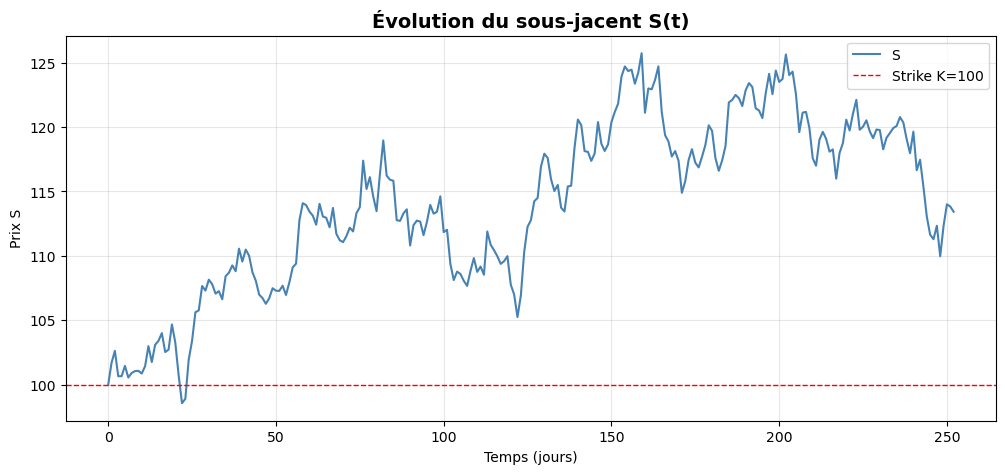

In [4]:
# Fixation de la seed pour reproductibilité
np.random.seed(10)

# Génération des chocs gaussiens
Z = np.random.normal(0, 1, N)

# Initialisation du DataFrame pour stocker les résultats
df = pd.DataFrame(index=range(N+1))
df["S"] = 0.0
df.loc[0, "S"] = S0

# Simulation du chemin de prix
for t in range(N):
    df.loc[t+1, "S"] = df.loc[t, "S"] * np.exp(
        (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[t]
    )

# Affichage des premières valeurs
print("Premières valeurs du sous-jacent :")
print(df[["S"]].head())

# Graphique du chemin simulé
plt.figure(figsize=(12, 5))
df["S"].plot(linewidth=1.5, color='steelblue')
plt.axhline(y=K, color='red', linestyle='--', label=f'Strike K={K}', linewidth=1)
plt.title("Évolution du sous-jacent S(t)", fontsize=14, fontweight='bold')
plt.xlabel("Temps (jours)")
plt.ylabel("Prix S")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. Calcul du prix du call et du P&L réel

À chaque instant $t$, on calcule :
- Le prix du call $C(S_t, T-t)$
- Le P&L réel $= C_{t+1} - C_t$

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_7996\3605147557.py:4: RuntimeWarning: divide by zero encountered in scalar divide
  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))


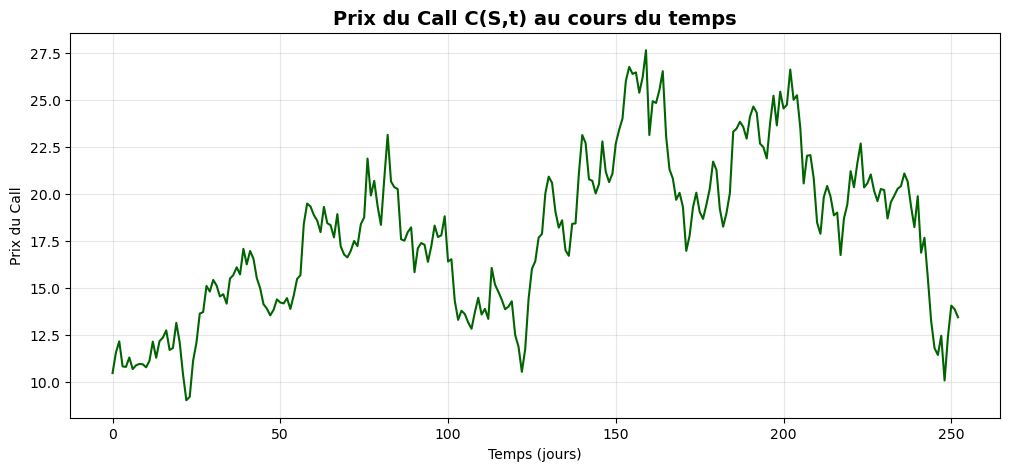


Prix initial du call : 10.4506
Payoff final (max(S-K, 0)) : 13.4255
Prix final du call : 13.4255


In [5]:
# Calcul du prix du call à chaque instant
df['price_call'] = 0.0

for t in range(len(df)):
    T_t = T - t * dt  # Temps restant jusqu'à maturité
    df.loc[t, 'price_call'] = call_price(df.loc[t, 'S'], K, r, sigma, T_t)

# Calcul du P&L réel (variation du prix du call)
df['PnL_reel'] = df['price_call'] - df['price_call'].shift(1)

# Graphique de l'évolution du prix du call
plt.figure(figsize=(12, 5))
df['price_call'].plot(linewidth=1.5, color='darkgreen')
plt.title("Prix du Call C(S,t) au cours du temps", fontsize=14, fontweight='bold')
plt.xlabel("Temps (jours)")
plt.ylabel("Prix du Call")
plt.grid(alpha=0.3)
plt.show()

print(f"\nPrix initial du call : {df.loc[0, 'price_call']:.4f}")
print(f"Payoff final (max(S-K, 0)) : {max(df.loc[N, 'S'] - K, 0):.4f}")
print(f"Prix final du call : {df.loc[N, 'price_call']:.4f}")

## 6. Calcul des Greeks

On calcule les 3 principaux Greeks à chaque instant :
- $\Delta$ : hedge ratio
- $\Gamma$ : ajustement de second ordre
- $\Theta$ : effet du temps

⚠️ **Note** : Ces valeurs sont exprimées **par an**. Pour obtenir la variation sur un jour, il faut multiplier Theta par $dt$.

In [6]:
# Calcul des Greeks à chaque instant
df['Delta'] = 0.0
df['Gamma'] = 0.0
df['theta'] = 0.0

for t in range(len(df)):
    T_t = T - t * dt
    df.loc[t, 'Delta'] = delta(df.loc[t, 'S'], K, r, sigma, T_t)
    df.loc[t, 'Gamma'] = gamma(df.loc[t, 'S'], K, r, sigma, T_t)
    df.loc[t, 'theta'] = theta(df.loc[t, 'S'], K, r, sigma, T_t)

# Affichage des Greeks initiaux
print("Greeks à t=0 (option ATM) :")
print(f"  Delta = {df.loc[0, 'Delta']:.4f}")
print(f"  Gamma = {df.loc[0, 'Gamma']:.6f}")
print(f"  Theta = {df.loc[0, 'theta']:.4f} (annualisé)")
print(f"  Theta quotidien = {df.loc[0, 'theta'] * dt:.6f}")

Greeks à t=0 (option ATM) :
  Delta = 0.6368
  Gamma = 0.018762
  Theta = -6.4140 (annualisé)
  Theta quotidien = -0.025452


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_7996\3605147557.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_7996\3605147557.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_7996\3605147557.py:17: RuntimeWarning: invalid value encountered in scalar divide
  return norm.pdf(d1) / (S * sigma * np.sqrt(T))
C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_7996\3605147557.py:21: RuntimeWarning: divide by zero encountered in scalar divide
  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_7996\3605147557.py:23: RuntimeWarning: invalid value encountered in scalar divide
  return (- (S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))


## 7. P&L approximé via les Greeks (Taylor ordre 2)

On utilise l'approximation de Taylor pour estimer la variation du prix :
$$\Delta C \approx \Delta \cdot \Delta S + \frac{1}{2}\Gamma \cdot (\Delta S)^2 + \Theta \cdot \Delta t$$

Cette formule permet de décomposer le P&L en 3 contributions :
1. **Effet Delta** : linéaire en $\Delta S$
2. **Effet Gamma** : quadratique en $(\Delta S)^2$
3. **Effet Theta** : décroissance temporelle

In [8]:
# Calcul de la variation du spot
df['dS'] = df['S'] - df['S'].shift()

# P&L approximé via les Greeks (formule de Taylor)
df['Pnl_greeks'] = (
    df['Delta'] * df['dS']                  # Terme linéaire (Delta)
    + 0.5 * df['Gamma'] * (df['dS']**2)     # Terme quadratique (Gamma)
    + df['theta'] * dt                       # Time decay (Theta quotidien)
)

# Affichage des premières lignes
print("\nPremières lignes du DataFrame :")
df[['S', 'price_call', 'Delta', 'Gamma', 'PnL_reel', 'Pnl_greeks']].head(10)


Premières lignes du DataFrame :


,S,price_call,Delta,Gamma,PnL_reel,Pnl_greeks
0,100.000000,10.450584,0.636831,0.018762,NaN,NaN
1,101.703900,11.536626,0.667838,0.017886,1.086043,1.138022
2,102.636781,12.141298,0.684123,0.017395,0.604671,0.619709
3,100.669734,10.804268,0.648579,0.018534,-1.337029,-1.265646
4,100.671085,10.779408,0.648369,0.018576,-0.024860,-0.024877
5,101.474320,11.280202,0.662913,0.018176,0.500793,0.512376
6,100.569857,10.662344,0.646008,0.018715,-0.617857,-0.602433
7,100.918854,10.863038,0.652281,0.018567,0.200694,0.202861
8,101.068994,10.935217,0.654843,0.018527,0.072179,0.072546
9,101.086492,10.920675,0.654949,0.018559,-0.014542,-0.014558


## 8. Analyse de l'erreur d'approximation

On mesure l'écart relatif entre le P&L réel et le P&L approximé :
$$\text{Erreur} = \left(\frac{\text{P&L Greeks}}{\text{P&L Réel}} - 1\right) \times 100\%$$

Cette erreur provient des termes d'ordre supérieur négligés dans l'approximation de Taylor (Vanna, Volga, etc.).

In [9]:
# Calcul de l'erreur relative (en %)
df['Erreur'] = (df['Pnl_greeks'] / df['PnL_reel'] - 1) * 100

# Statistiques sur l'erreur
erreur_clean = df['Erreur'].replace([np.inf, -np.inf], np.nan).dropna()

print("\n=== Statistiques de l'erreur d'approximation ===")
print(f"Erreur moyenne : {erreur_clean.mean():.2f}%")
print(f"Erreur médiane : {erreur_clean.median():.2f}%")
print(f"Écart-type : {erreur_clean.std():.2f}%")
print(f"Max : {erreur_clean.max():.2f}%")
print(f"Min : {erreur_clean.min():.2f}%")

# Affichage du DataFrame complet
display(df)


=== Statistiques de l'erreur d'approximation ===
Erreur moyenne : 0.17%
Erreur médiane : 0.02%
Écart-type : 2.01%
Max : 9.10%
Min : -7.10%


,S,price_call,PnL_reel,Delta,Gamma,theta,dS,Pnl_greeks,Erreur
0,100.000000,10.450584,NaN,0.636831,1.876202e-02,-6.414028,NaN,NaN,NaN
1,101.703900,11.536626,1.086043,0.667838,1.788604e-02,-6.519405,1.703900,1.138022,4.786091
2,102.636781,12.141298,0.604671,0.684123,1.739526e-02,-6.568684,0.932882,0.619709,2.486892
3,100.669734,10.804268,-1.337029,0.648579,1.853446e-02,-6.481110,-1.967048,-1.265646,-5.338935
4,100.671085,10.779408,-0.024860,0.648369,1.857554e-02,-6.489770,0.001351,-0.024877,0.069684
...,...,...,...,...,...,...,...,...,...
248,109.974017,10.053395,-2.384980,0.999933,9.866456e-05,-5.019526,-2.365190,-2.384673,-0.012848
249,112.331525,12.391032,2.337637,1.000000,9.049883e-08,-4.997047,2.357508,2.337679,0.001804
250,114.004182,14.043857,1.652826,1.000000,2.775355e-13,-4.998016,1.672657,1.652824,-0.000118
251,113.827474,13.847313,-0.196544,1.000000,2.504760e-24,-4.999008,-0.176709,-0.196546,0.001001


## 9. Visualisation analytique : Erreur et décomposition du P&L

### Distribution de l'erreur et contribution par Greek

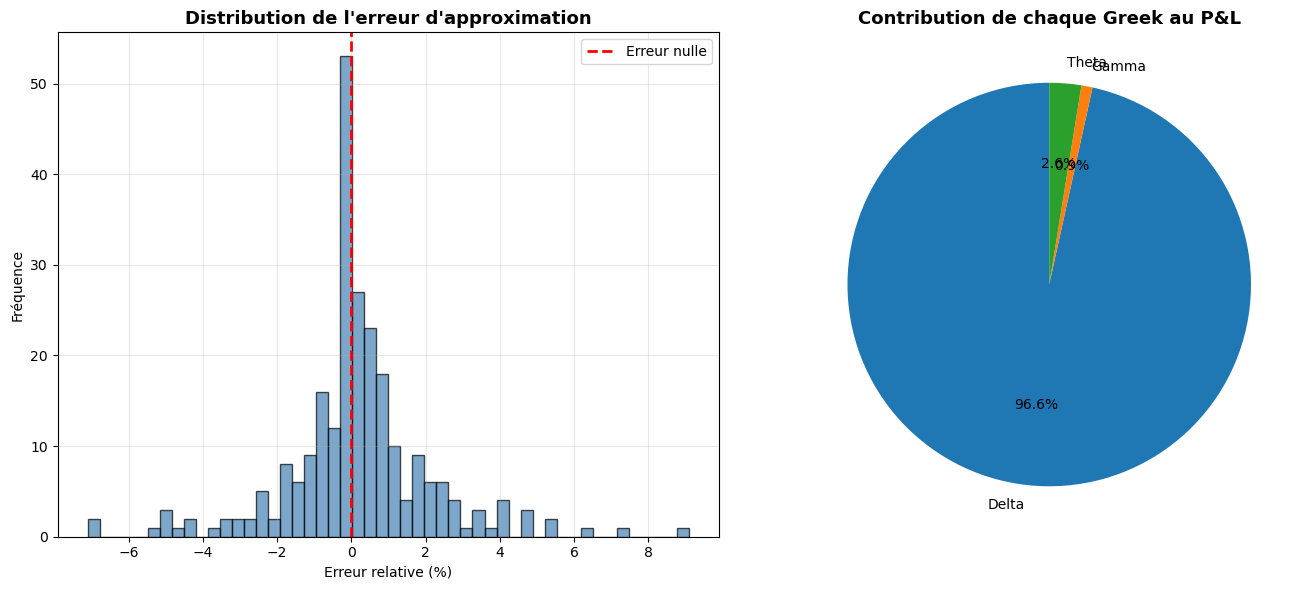

In [11]:
# Calcul des contributions de chaque Greek
df['Contrib_Delta'] = df['Delta'] * df['dS']
df['Contrib_Gamma'] = 0.5 * df['Gamma'] * (df['dS']**2)
df['Contrib_Theta'] = df['theta'] * dt

# Nettoyage de l'erreur
erreur_clean = df['Erreur'].replace([np.inf, -np.inf], np.nan).dropna()

# Graphiques
plt.figure(figsize=(14, 6))

# Histogramme de l'erreur
plt.subplot(1, 2, 1)
erreur_clean.hist(bins=50, alpha=0.7, color='steelblue', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Erreur nulle')
plt.title("Distribution de l'erreur d'approximation", fontsize=13, fontweight='bold')
plt.xlabel("Erreur relative (%)")
plt.ylabel("Fréquence")
plt.legend()
plt.grid(alpha=0.3)

# Pizza des contributions
plt.subplot(1, 2, 2)
contributions = pd.Series({
    'Delta': df['Contrib_Delta'].abs().sum(),
    'Gamma': df['Contrib_Gamma'].abs().sum(),
    'Theta': df['Contrib_Theta'].abs().sum()
})
contributions.plot(kind='pie', autopct='%1.1f%%', startangle=90, 
                   colors=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title("Contribution de chaque Greek au P&L", fontsize=13, fontweight='bold')
plt.ylabel('')

plt.tight_layout()
plt.show()

## 10. Conclusions

### Observations clés
1. **Précision de l'approximation** : L'approche Delta-Gamma (Taylor ordre 2) fournit une approximation très proche du P&L réel pour des variations modérées du spot.

2. **Sources d'erreur** :
   - Termes d'ordre 3+ négligés (Vanna, Volga)
   - Erreur de discrétisation temporelle
   - Hypothèse de volatilité constante

3. **Cas limites** :
   - L'approximation est meilleure pour les options ATM
   - L'erreur augmente en cas de gros mouvements ($\Delta S$ élevé)
   - À l'approche de la maturité, Gamma et Theta deviennent très sensibles

### Applications pratiques
- **Market making** : estimation rapide du P&L d'un portefeuille d'options
- **Risk management** : évaluation de l'exposition aux Greeks
- **Optimisation de la couverture** : détermination de la fréquence de rebalancement optimale
